In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.utils import shuffle

plt.rcParams["figure.figsize"] = (8,5)

DATASET_PATH = "aclImdb"

In [2]:
import os

os.makedirs("images", exist_ok=True)

In [3]:
def load_reviews(folder):

    reviews = []
    labels = []

    pos_path = os.path.join(folder, "pos")
    neg_path = os.path.join(folder, "neg")

    # Positive reviews
    for filename in os.listdir(pos_path):

        filepath = os.path.join(pos_path, filename)

        with open(filepath, encoding="utf-8") as f:

            reviews.append(f.read())
            labels.append(1)

    # Negative reviews
    for filename in os.listdir(neg_path):

        filepath = os.path.join(neg_path, filename)

        with open(filepath, encoding="utf-8") as f:

            reviews.append(f.read())
            labels.append(0)

    return reviews, np.array(labels)

In [4]:
x_train, y_train = load_reviews(
    os.path.join(DATASET_PATH, "train")
)

x_test, y_test = load_reviews(
    os.path.join(DATASET_PATH, "test")
)

print("Train :", len(x_train))
print("Test  :", len(x_test))

Train : 25000
Test  : 25000


In [5]:
x_train, y_train = shuffle(
    x_train,
    y_train,
    random_state=42
)

x_test, y_test = shuffle(
    x_test,
    y_test,
    random_state=42
)

In [6]:
print("="*80)
print(x_train[0])
print("="*80)
print()
print("Label :", "Positive" if y_train[0] else "Negative")

In Panic In The Streets Richard Widmark plays U.S. Navy doctor who has his week rudely interrupted with a corpse that contains plague. As cop Paul Douglas properly points out the guy died from two bullets in the chest. That's not the issue here, the two of them become unwilling partners in an effort to find the killers and anyone else exposed to the disease.<br /><br />As was pointed out by any number of people, for some reason director Elia Kazan did not bother to cast the small parts with anyone that sounds like they're from Louisiana. Having been to New Orleans where the story takes place I can personally attest to that. Richard Widmark and his wife Barbara Bel Geddes can be excused because as a Navy doctor he could be assigned there, but for those that are natives it doesn't work.<br /><br />But with plague out there and the news being kept a secret, the New Orleans PD starts a dragnet of the city's underworld. The dead guy came off a ship from Europe and he had underworld connecti

In [7]:
print("Training samples :", len(x_train))
print("Testing samples  :", len(x_test))
print()
print("Positive :", np.sum(y_train))
print("Negative :", len(y_train)-np.sum(y_train))

Training samples : 25000
Testing samples  : 25000

Positive : 12500
Negative : 12500


In [8]:
df = pd.DataFrame({
    "Review":x_train,
    "Label":y_train
})
df.head()

,Review,Label
0,In Panic In The Streets Richard Widmark plays ...,1
1,If you ask me the first one was really better ...,0
2,I am a big fan a Faerie Tale Theatre and I've ...,1
3,I just finished reading a book about Dillinger...,0
4,Greg Davis and Bryan Daly take some crazed sta...,0


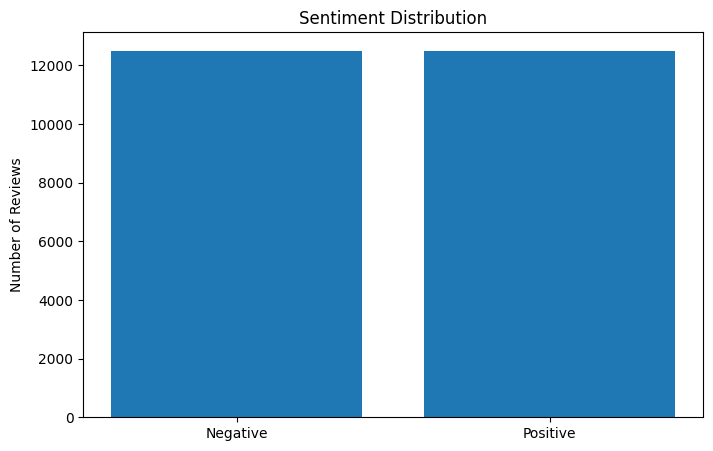

In [9]:
counts = df["Label"].value_counts()
plt.bar(
    ["Negative","Positive"],
    [counts[0],counts[1]]
)
plt.title("Sentiment Distribution")
plt.ylabel("Number of Reviews")
plt.savefig(
    "images/sentiment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

Minimum : 10
Maximum : 2470
Average : 233.7872


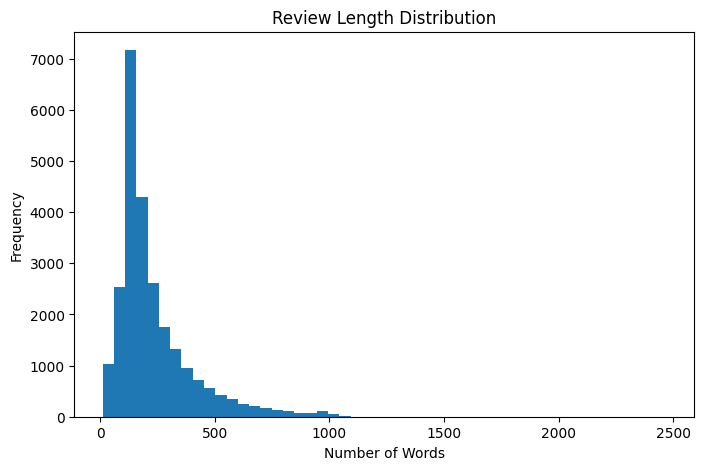

Maximum sequence length : 200


In [10]:
review_length = [
    len(review.split())
    for review in x_train
]

print("Minimum :", np.min(review_length))
print("Maximum :", np.max(review_length))
print("Average :", np.mean(review_length))

plt.hist(review_length, bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.savefig(
    "images/review_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

MAX_LEN = 200
print("Maximum sequence length :", MAX_LEN)

In [11]:
# Vocabulary size
VOCAB_SIZE = 10000

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(x_train)

print("Vocabulary Size:", VOCAB_SIZE)
print("Actual Vocabulary:", len(tokenizer.word_index))

Vocabulary Size: 10000
Actual Vocabulary: 88583


In [12]:
x_train_seq = tokenizer.texts_to_sequences(x_train)
x_test_seq = tokenizer.texts_to_sequences(x_test)

print("Original Review:")
print(x_train[0][:200])

print("\nEncoded Sequence:")
print(x_train_seq[0][:40])

Original Review:
In Panic In The Streets Richard Widmark plays U.S. Navy doctor who has his week rudely interrupted with a corpse that contains plague. As cop Paul Douglas properly points out the guy died from two bul

Encoded Sequence:
[9, 4044, 9, 2, 1984, 743, 3286, 296, 1204, 588, 3023, 1038, 35, 45, 25, 1265, 1, 7577, 17, 4, 3560, 13, 1360, 3185, 15, 999, 721, 1764, 2877, 754, 44, 2, 230, 1128, 37, 105, 3585, 9, 2, 4518]


In [13]:
x_train_pad = pad_sequences(
    x_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

x_test_pad = pad_sequences(
    x_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print(x_train_pad.shape)
print(x_test_pad.shape)

(25000, 200)
(25000, 200)


In [14]:
print("First sequence length:", len(x_train_pad[0]))
print()
print(x_train_pad[0])

First sequence length: 200

[   9 4044    9    2 1984  743 3286  296 1204  588 3023 1038   35   45
   25 1265    1 7577   17    4 3560   13 1360 3185   15  999  721 1764
 2877  754   44    2  230 1128   37  105 3585    9    2 4518  196   22
    2 1830  131    2  105    5   96  411 8776 5795    9   33  779    6
  167    2 2162    3  257  332 3766    6    2 3494    8    8   15   14
 3367   44   32   99  609    5   82   16   47  280  165    1 7094  120
   22 1409    6  175    2  390  529   17  257   13  932   38  504   37
    1  258   75    6  160 5075  119    2   63  302  271   11   68 1272
    1    6   13  743 3286    3   25  320 2187    1    1   68   28    1
   86   15    4 3023 1038   27   98   28 4940   48   19   16  146   13
   24 5976   10  150  155    8    8   19   17 3185   44   48    3    2
 1632  110  826    4 1000    2  160 5075    1  515    4    1    5    2
 9458 5559    2  349  230  383  123    4 1690   37 2374    3   27   67
 5559 5622    4  160 5075 1560  230  254   32  71

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [16]:
EMBEDDING_DIM = 128

model = Sequential()

model.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN
    )
)

model.add(LSTM(128))
model.add(Dropout(0.5))
model.add(Dense(1, activation="sigmoid"))

model.summary()

c:\Users\ADMIN\AppData\Local\Python\pythoncore-3.10-64\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [19]:
history = model.fit(
    x_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

loss, accuracy = model.evaluate(
    x_test_pad,
    y_test,
    verbose=1
)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 161ms/step - accuracy: 0.5196 - loss: 0.6927 - val_accuracy: 0.6570 - val_loss: 0.6636
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 152ms/step - accuracy: 0.5457 - loss: 0.6862 - val_accuracy: 0.5314 - val_loss: 0.6875
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 150ms/step - accuracy: 0.6373 - loss: 0.6321 - val_accuracy: 0.5900 - val_loss: 0.6558
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 154ms/step - accuracy: 0.6610 - loss: 0.6033 - val_accuracy: 0.6904 - val_loss: 0.7151
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 146ms/step - accuracy: 0.7851 - loss: 0.4943 - val_accuracy: 0.7940 - val_loss: 0.4707
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 142ms/step - accuracy: 0.8595 - loss: 0.3516 - val_accuracy: 0.8284 - val_loss: 0.4043
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 147ms/step - accuracy: 0.8924 - loss: 0.2798 - val_accuracy: 0.8178 - val_loss: 0.4220
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 150ms/step - accuracy: 0.9193 - loss: 0

In [20]:
loss, accuracy = model.evaluate(
    x_test_pad,
    y_test,
    verbose=1
)

print("="*50)
print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy:.4f}")
print("="*50)

782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.8342 - loss: 0.4352
Test Loss     : 0.4352
Test Accuracy : 0.8342


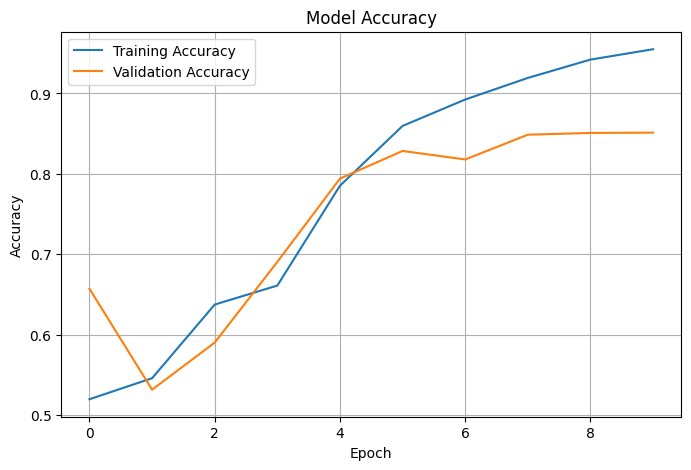

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.savefig(
    "images/accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

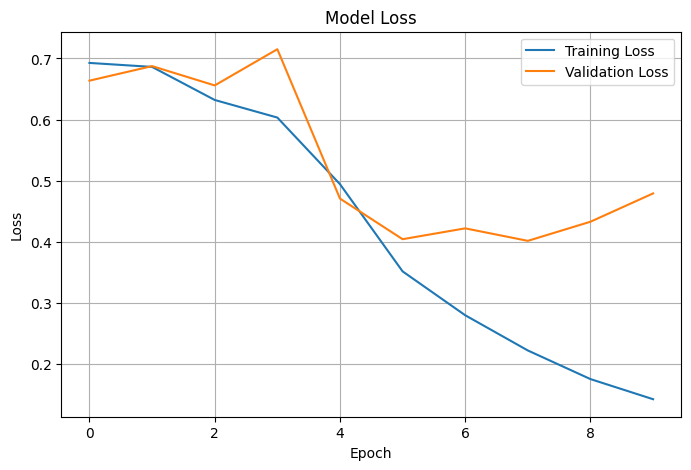

In [22]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.savefig(
    "images/loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [23]:
y_prob = model.predict(x_test_pad)

y_pred = (y_prob > 0.5).astype(int)

782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step


In [24]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative","Positive"]
))

              precision    recall  f1-score   support

    Negative       0.84      0.83      0.83     12500
    Positive       0.83      0.84      0.84     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000



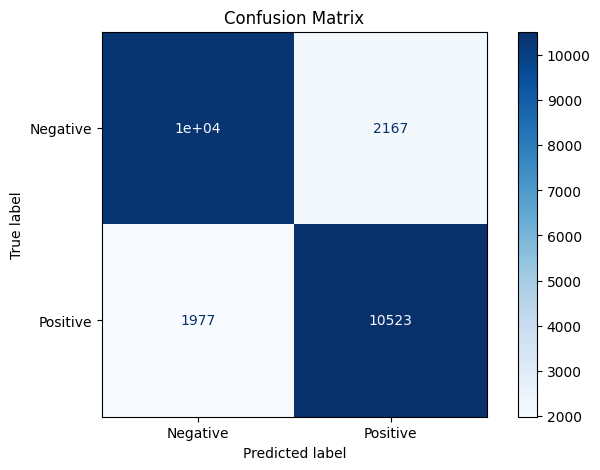

In [25]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative","Positive"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.savefig(
    "images/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [26]:
def predict_review(review):

    sequence = tokenizer.texts_to_sequences([review])

    sequence = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    probability = model.predict(sequence, verbose=0)[0][0]

    sentiment = "Positive" if probability >= 0.5 else "Negative"

    print("="*60)
    print("Review:")
    print(review)
    print("-"*60)
    print(f"Sentiment : {sentiment}")
    print(f"Probability: {probability:.4f}")
    print("="*60)

In [27]:
predict_review(
    "This movie was absolutely fantastic. The acting and story were amazing."
)

Review:
This movie was absolutely fantastic. The acting and story were amazing.
------------------------------------------------------------
Sentiment : Positive
Probability: 0.7796


In [28]:
predict_review(
    "This is the worst movie I have ever watched. It was boring and terrible."
)

Review:
This is the worst movie I have ever watched. It was boring and terrible.
------------------------------------------------------------
Sentiment : Negative
Probability: 0.0805


In [29]:
predict_review(
    "I hate you."
)

Review:
I hate you.
------------------------------------------------------------
Sentiment : Negative
Probability: 0.2452


In [30]:
predict_review(
    "I love you."
)

Review:
I love you.
------------------------------------------------------------
Sentiment : Negative
Probability: 0.3528


In [31]:
predict_review(
    "The book is very great, I think you should read it."
)

Review:
The book is very great, I think you should read it.
------------------------------------------------------------
Sentiment : Positive
Probability: 0.7808
